In [1]:
import numpy as np
import random

In [2]:
a = np.arange(1,11)
random.shuffle(a)
a

array([10,  7,  2,  5,  1,  3,  8,  4,  9,  6])

In [3]:
np.where(a % 2 == 0, a, 0)

array([10,  0,  2,  0,  0,  0,  8,  4,  0,  6])

In [4]:
a.reshape(2,5).ravel()
a = a * 3
a + a

array([60, 42, 12, 30,  6, 18, 48, 24, 54, 36])

In [5]:
import pandas as pd
import matplotlib as plt

In [6]:
pd.Series(a)

0    30
1    21
2     6
3    15
4     3
5     9
6    24
7    12
8    27
9    18
dtype: int64

In [7]:
pd.DataFrame(a.reshape(5,2))

,0,1
0,30,21
1,6,15
2,3,9
3,24,12
4,27,18


In [8]:
df = pd.read_csv('train_titanic.csv', index_col='PassengerId')

In [9]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [11]:
a = df['Fare'].quantile(0.95)

In [12]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df[df.Fare > 10]
df[[True, False, True] * 297]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [14]:
df.iloc[:10, 3:6]

,Sex,Age,SibSp
PassengerId,,,
1,male,22.0,1
2,female,38.0,1
3,female,26.0,0
4,female,35.0,1
5,male,35.0,0
6,male,NaN,0
7,male,54.0,0
8,male,2.0,3
9,female,27.0,0


In [15]:
df[df.Fare > 30].loc[:10, 'Survived' : 'Sex']

,Survived,Pclass,Name,Sex
PassengerId,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female
7,0,1,"McCarthy, Mr. Timothy J",male
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female


In [16]:
df["Title"] = df.Name.apply(lambda x : x[:x.find(".") + 1].split()[-1])

In [ ]:
df.groupby(["Title", "Pclass"]).agg({"Fare": ["mean", "median"]}).loc[("Mr.", 1)]

In [ ]:
df.groupby("Title").agg({"Fare": ["mean", "median"]}).loc["Mr.", ("Fare", "mean")] #функции агригации для Fare; первый уровень-Fare, второй-третий -> mean, median, .loc["Mr."] - доп аггригация для мистера

In [ ]:
df.isna().sum()/df.shape[0]


In [ ]:
df.Age.describe()


In [ ]:
df["Age"].fillna(df.Age.median()) #fillna() возвращает копию !
# еще мы можем использовать dropna(), выбрасывая значения, но тк у нас больший процент мы потеряем большой блок


In [ ]:
def age_group(age):
    if age < 12:
        return "child"
    elif 12 <= age < 18:
        return "teenager"
    elif 18 <= age < 27:
        return "young adult"
    elif 27 <= age < 55:
        return "adult"
    elif 55 <= age:
        return "old"
    else:
        return "unknown"

df["Group"] = df["Age"].apply(age_group)

In [17]:
df[["Survived", "Group"]].groupby("Group").agg(["count", "sum"])

True

In [ ]:
group_survived = df[["Survived", "Group"]].groupby("Group").agg(["count", "sum"])

In [ ]:
group_survived["persentage"] = group_survived[("Survived", "sum")]

In [24]:
df[["Survived", "Pclass", "Group"]].groupby(["Pclass", "Group"]).mean()

In [ ]:
# в cabin у нас много пропусков в возрасте, нам ее нужно не учитывать
df.drop("Cabin", axis=1, inplace=False)

In [25]:
df.rename({"Cabin": "Кабина"}, axis=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Кабина,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [27]:
a = pd.DataFrame(np.arange(32).reshape(8, 4), columns = ["one", "two", "three", "four"])
a.columns = ["one", "two", "three", "four"]

In [28]:
b = pd.DataFrame(np.arange(16).reshape(4, 4))

In [29]:
pd.concat([a, b])

,one,two,three,four,0,1,2,3
0,0.0,1.0,2.0,3.0,NaN,NaN,NaN,NaN
1,4.0,5.0,6.0,7.0,NaN,NaN,NaN,NaN
2,8.0,9.0,10.0,11.0,NaN,NaN,NaN,NaN
3,12.0,13.0,14.0,15.0,NaN,NaN,NaN,NaN
4,16.0,17.0,18.0,19.0,NaN,NaN,NaN,NaN
5,20.0,21.0,22.0,23.0,NaN,NaN,NaN,NaN
6,24.0,25.0,26.0,27.0,NaN,NaN,NaN,NaN
7,28.0,29.0,30.0,31.0,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,0.0,1.0,2.0,3.0
1,NaN,NaN,NaN,NaN,4.0,5.0,6.0,7.0


<Axes: ylabel='Frequency'>

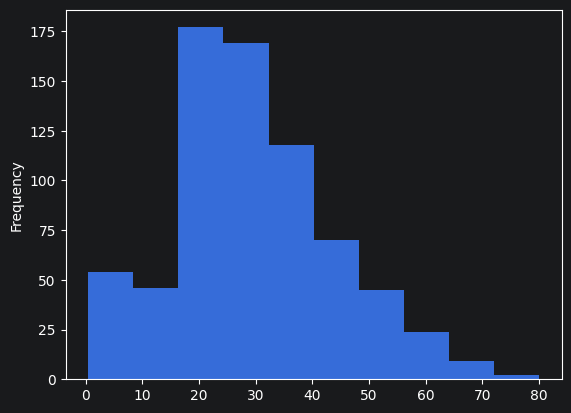

In [30]:
df.Age.plot.hist() # см plotly, seaborn
# streamlead - обертка для питона чтобы выглядело как python notebook

<Axes: >

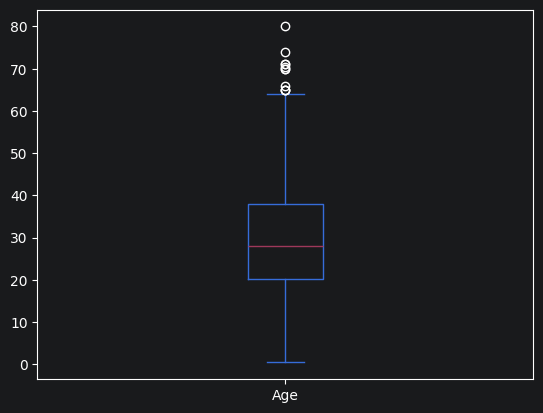

In [31]:
df.Age.plot.box() # IQR-график